##Premium Quote Prediction - Car

##Workflow

1. Import libraries
2. Load dataset
3. Data inspection (head, info, describe)
4. Duplicate analysis
5. Missing value analysis
6. Exploratory Data Analysis (visualizations)
7. Train/test split
8. Build preprocessing + model pipeline
9. Train the model
10. Evaluation (MAE, RMSE, R²)
11. Save the trained pipeline

##Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

##Load Dataset

In [3]:
df_health = pd.read_csv('/content/acko_health_quotation.csv')



##Data inspection

In [4]:
df_health.shape

#(20000, 24)

(20000, 24)

In [5]:
df_health.head()

,record_id,plan_name,plan_category,age,gender,num_members,city_tier,state,bmi_category,smoke,...,deductible,num_addons,addons_list,has_maternity,has_opd,policy_tenure,prev_insurer,annual_premium,gst_amount,total_premium
0,AHQ000000,Family Floater Standard,Family,23,Male,4,2,Punjab,Normal,0,...,25000,1,dental_vision,0,0,2,Bajaj Allianz,78300.0,14094.0,92394.0
1,AHQ000001,Critical Illness,Specialty,43,Female,1,3,Delhi,Overweight,0,...,0,0,NaN,0,0,1,Niva Bupa,53500.0,9630.0,63130.0
2,AHQ000002,Family Floater Premium,Family,20,Female,5,1,Madhya Pradesh,Normal,0,...,0,0,NaN,0,0,2,SBI Health,181400.0,32652.0,214052.0
3,AHQ000003,Senior Citizen,Senior,61,Female,2,1,Haryana,Overweight,0,...,5000,3,maternity|critical_illness_rider|international...,1,0,1,Care Health,147000.0,26460.0,173460.0
4,AHQ000004,Family Floater Standard,Family,43,Male,2,3,Kerala,Overweight,0,...,0,1,personal_accident,0,0,1,SBI Health,37200.0,6696.0,43896.0


In [6]:
df_health.columns

Index(['record_id', 'plan_name', 'plan_category', 'age', 'gender',
       'num_members', 'city_tier', 'state', 'bmi_category', 'smoke',
       'has_pre_existing', 'annual_checkup', 'ncb_years', 'sum_insured',
       'deductible', 'num_addons', 'addons_list', 'has_maternity', 'has_opd',
       'policy_tenure', 'prev_insurer', 'annual_premium', 'gst_amount',
       'total_premium'],
      dtype='object')

In [7]:
df_health.describe()

,age,num_members,city_tier,smoke,has_pre_existing,annual_checkup,ncb_years,sum_insured,deductible,num_addons,has_maternity,has_opd,policy_tenure,annual_premium,gst_amount,total_premium
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.00000,2.000000e+04
mean,45.978550,2.312700,1.902200,0.153350,0.266650,0.451800,1.495700,8.944425e+05,6388.500000,1.995350,0.286900,0.288450,1.540400,1.108002e+05,19944.03420,1.307442e+05
std,16.416558,1.266925,0.768157,0.360334,0.442219,0.497684,1.473258,1.022656e+06,11416.264026,1.408271,0.452326,0.453053,0.730681,1.065603e+05,19180.85273,1.257411e+05
min,18.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.000000e+05,0.000000,0.000000,0.000000,0.000000,1.000000,3.800000e+03,684.00000,4.484000e+03
25%,32.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.000000e+05,0.000000,1.000000,0.000000,0.000000,1.000000,3.970000e+04,7146.00000,4.684600e+04
50%,46.000000,2.000000,2.000000,0.000000,0.000000,0.000000,1.000000,5.000000e+05,0.000000,2.000000,0.000000,0.000000,1.000000,7.690000e+04,13842.00000,9.074200e+04
75%,60.000000,3.000000,3.000000,0.000000,1.000000,1.000000,3.000000,1.000000e+06,10000.000000,3.000000,1.000000,1.000000,2.000000,1.427000e+05,25686.00000,1.683860e+05
max,74.000000,5.000000,3.000000,1.000000,1.000000,1.000000,5.000000,1.000000e+07,50000.000000,4.000000,1.000000,1.000000,3.000000,1.090800e+06,196344.00000,1.287144e+06


In [8]:
df_health.describe(include='object')

,record_id,plan_name,plan_category,gender,state,bmi_category,addons_list,prev_insurer
count,20000,20000,20000,20000,20000,20000,16033,20000
unique,20000,9,4,2,15,3,1093,8
top,AHQ019983,Senior Citizen,Family,Male,West Bengal,Normal,opd_cover,United India
freq,1,5251,7534,10702,1384,9996,602,2582


In [9]:
df_health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   record_id         20000 non-null  object 
 1   plan_name         20000 non-null  object 
 2   plan_category     20000 non-null  object 
 3   age               20000 non-null  int64  
 4   gender            20000 non-null  object 
 5   num_members       20000 non-null  int64  
 6   city_tier         20000 non-null  int64  
 7   state             20000 non-null  object 
 8   bmi_category      20000 non-null  object 
 9   smoke             20000 non-null  int64  
 10  has_pre_existing  20000 non-null  int64  
 11  annual_checkup    20000 non-null  int64  
 12  ncb_years         20000 non-null  int64  
 13  sum_insured       20000 non-null  int64  
 14  deductible        20000 non-null  int64  
 15  num_addons        20000 non-null  int64  
 16  addons_list       16033 non-null  object

##Duplicate Analysis

In [10]:
df_health.duplicated().sum()

np.int64(0)

In [11]:
df_health.drop(columns=['record_id']).duplicated().sum()

np.int64(0)

##Missing Value Analysis

In [12]:
df_health.isna().sum()

,0
record_id,0
plan_name,0
plan_category,0
age,0
gender,0
num_members,0
city_tier,0
state,0
bmi_category,0
smoke,0


##Imputing Null values in 'addons_list'


In [13]:
df_health['addons_list'].head()

,addons_list
0,dental_vision
1,NaN
2,NaN
3,maternity|critical_illness_rider|international...
4,personal_accident


In [14]:
df_health['addons_list'].isna().mean()*100

np.float64(19.835)

In [15]:
df_health.loc[df_health['addons_list'].isna(), "num_addons"].value_counts()

,count
num_addons,
0,3967


In [16]:
(df_health.loc[df_health["addons_list"].isna(), "num_addons"] == 0).all()

np.True_

In [17]:
df_health["addons_list"] = df_health["addons_list"].fillna("No Add-ons")

In [18]:
df_health['addons_list'].isna().sum()

np.int64(0)

##Inference

 Inference : The addons_list column contains null values only for customers with num_addons = 0. Therefore, these null values indicate that no add-ons were selected rather than missing information. Hence, they were replaced with "No Add-ons".

##Exploratory Data Analysis(Visualization)

#1. Distribution of Target Variable (total_premium)

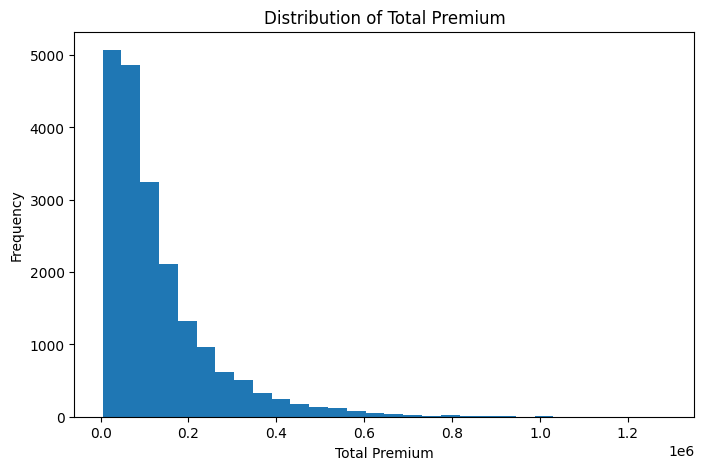

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_health["total_premium"], bins=30)
plt.title("Distribution of Total Premium")
plt.xlabel("Total Premium")
plt.ylabel("Frequency")
plt.show()

#Inference:



*   The total_premium distribution is positively (right) skewed, with most customers paying lower premiums.
*   A small number of policies have very high premium values, indicating the presence of outliers.
*   The target variable is not normally distributed, which is common in insurance pricing datasets.

##2. Age vs Total Premium

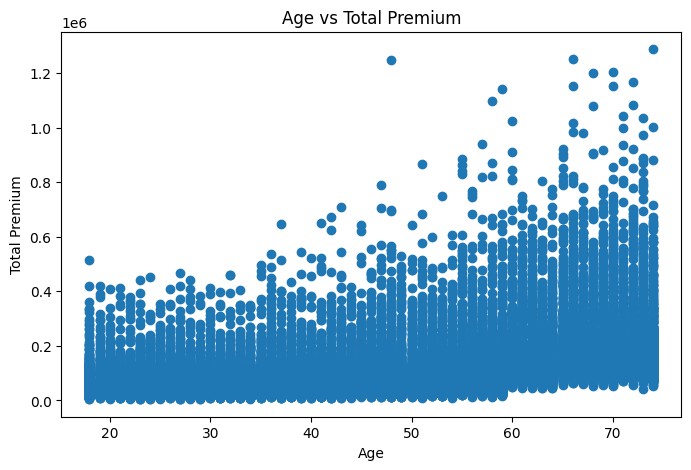

In [21]:
plt.figure(figsize=(8,5))
plt.scatter(df_health["age"], df_health["total_premium"])
plt.title("Age vs Total Premium")
plt.xlabel("Age")
plt.ylabel("Total Premium")
plt.show()

#Inference:

* There is a positive relationship between age and total premium.
* Older policyholders generally tend to have higher insurance premiums due to increased health risks.
* Premium variability also increases with age, indicating greater differences in premium amounts among senior customers.

##3. BMI Category vs Premium

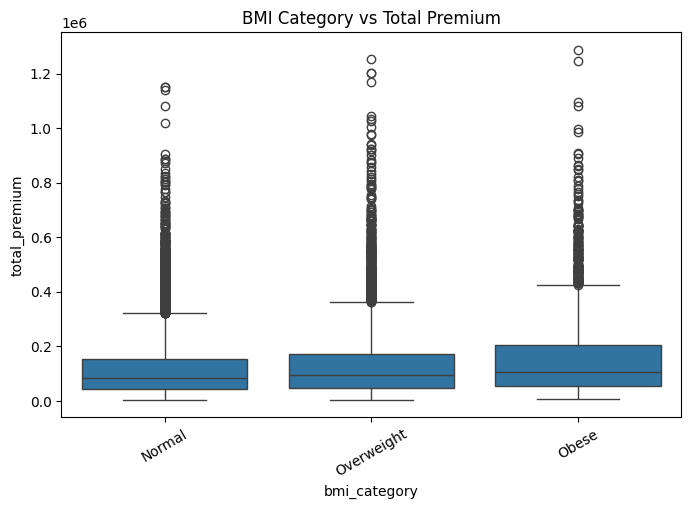

In [23]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x="bmi_category",
            y="total_premium",
            data=df_health)

plt.xticks(rotation=30)
plt.title("BMI Category vs Total Premium")
plt.show()

#Inference:

* Customers in the Obese BMI category generally have higher premium values than those in the Normal and Overweight categories.
* Higher BMI is associated with increased health risk, leading to comparatively higher insurance premiums.
* All BMI categories contain some high-premium outliers.

##4. Plan Category vs Premium

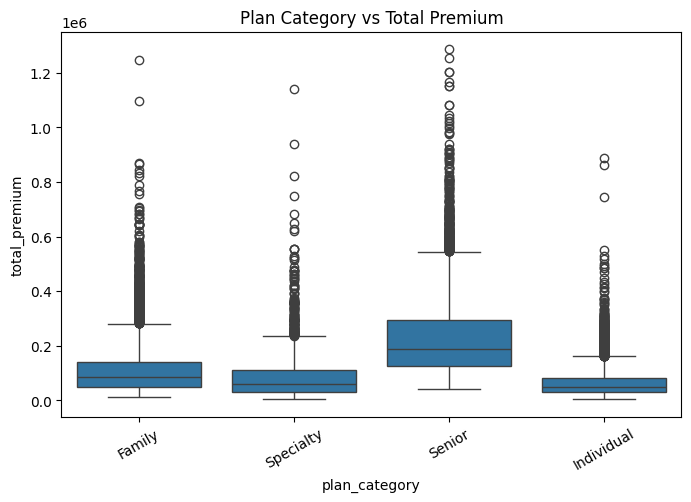

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(x="plan_category",
            y="total_premium",
            data=df_health)

plt.xticks(rotation=30)
plt.title("Plan Category vs Total Premium")
plt.show()

#Inference:

* The Senior plan category has the highest median premium among all plan categories.
* Individual and Specialty plans generally have lower premium distributions.
* Premium varies significantly across different insurance plan categories.

##5. Correlation Heatmap

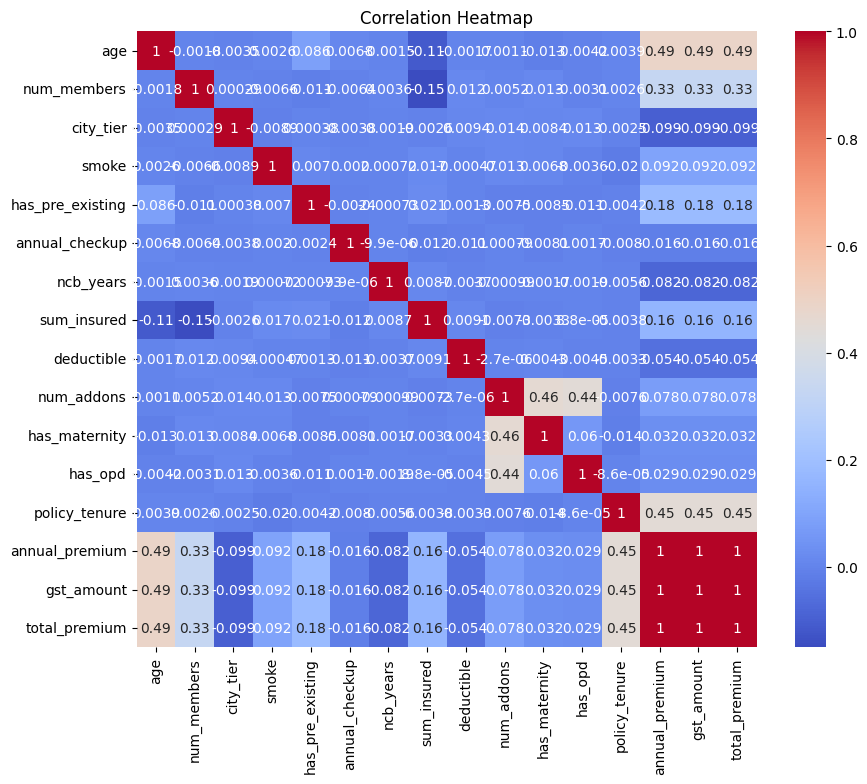

In [25]:
plt.figure(figsize=(10,8))

sns.heatmap(df_health.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

#Inference:

* Age (≈0.49) and policy_tenure (≈0.45) show moderate positive correlations with the total premium.
* Most numerical features have weak correlations with the target, indicating that premium prediction depends on multiple factors rather than a single variable.
* annual_premium, gst_amount, and total_premium are highly correlated because GST is calculated from the annual premium and contributes directly to the total premium.

##6. Smoking vs Premium

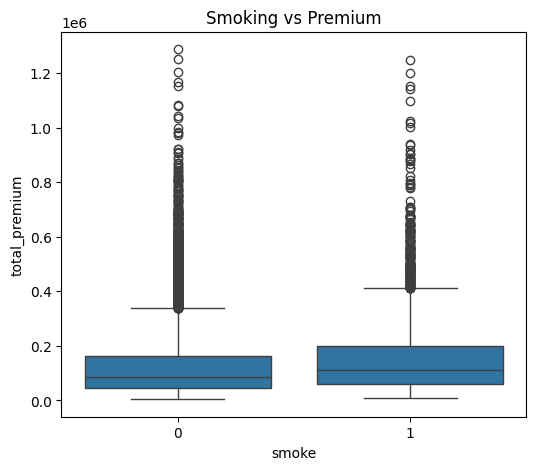

In [26]:
plt.figure(figsize=(6,5))

sns.boxplot(x="smoke",
            y="total_premium",
            data=df_health)

plt.title("Smoking vs Premium")
plt.show()

#Inference:

* Smokers generally have higher premium values compared to non-smokers.
* Smoking status has a noticeable impact on insurance pricing due to increased health risks.
* Both smoker and non-smoker groups contain outliers with exceptionally high premiums.

##Imports for Model Building

In [28]:
#Data Preprocessing

from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

#Pipeline

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

#Model Building

from sklearn.ensemble import RandomForestRegressor

#Evaluation Metrics

from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score


##Splitting Feature Columns(X) and Target Column(Y)

In [29]:
df_health.columns

Index(['record_id', 'plan_name', 'plan_category', 'age', 'gender',
       'num_members', 'city_tier', 'state', 'bmi_category', 'smoke',
       'has_pre_existing', 'annual_checkup', 'ncb_years', 'sum_insured',
       'deductible', 'num_addons', 'addons_list', 'has_maternity', 'has_opd',
       'policy_tenure', 'prev_insurer', 'annual_premium', 'gst_amount',
       'total_premium'],
      dtype='object')

In [36]:
# Split Features and Target

X = df_health.drop(
    columns=[
        "record_id",
        "annual_premium",
        "gst_amount",
        "total_premium"
    ]
)

Y = df_health["total_premium"]


In [37]:
print(X.columns)
print(Y.head())

Index(['plan_name', 'plan_category', 'age', 'gender', 'num_members',
       'city_tier', 'state', 'bmi_category', 'smoke', 'has_pre_existing',
       'annual_checkup', 'ncb_years', 'sum_insured', 'deductible',
       'num_addons', 'addons_list', 'has_maternity', 'has_opd',
       'policy_tenure', 'prev_insurer'],
      dtype='object')
0     92394.0
1     63130.0
2    214052.0
3    173460.0
4     43896.0
Name: total_premium, dtype: float64


##Splitting Train and Test Data

In [38]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((16000, 20), (4000, 20), (16000,), (4000,))

In [39]:
Num_Col = X.select_dtypes(include=['int64','float64'])
Num_Col

,age,num_members,city_tier,smoke,has_pre_existing,annual_checkup,ncb_years,sum_insured,deductible,num_addons,has_maternity,has_opd,policy_tenure
0,23,4,2,0,0,0,0,750000,25000,1,0,0,2
1,43,1,3,0,0,0,4,2500000,0,0,0,0,1
2,20,5,1,0,1,0,0,750000,0,0,0,0,2
3,61,2,1,0,1,1,3,1000000,5000,3,1,0,1
4,43,2,3,0,0,1,0,1000000,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,22,2,1,0,0,1,0,1000000,0,2,1,0,1
19996,34,2,3,0,0,1,0,2500000,10000,1,1,0,1
19997,63,5,2,0,0,0,1,1000000,0,2,0,0,1
19998,58,2,3,0,1,1,0,300000,5000,1,1,0,2


In [40]:
Cat_Col = X.select_dtypes(include='object')
Cat_Col

,plan_name,plan_category,gender,state,bmi_category,addons_list,prev_insurer
0,Family Floater Standard,Family,Male,Punjab,Normal,dental_vision,Bajaj Allianz
1,Critical Illness,Specialty,Female,Delhi,Overweight,No Add-ons,Niva Bupa
2,Family Floater Premium,Family,Female,Madhya Pradesh,Normal,No Add-ons,SBI Health
3,Senior Citizen,Senior,Female,Haryana,Overweight,maternity|critical_illness_rider|international...,Care Health
4,Family Floater Standard,Family,Male,Kerala,Overweight,personal_accident,SBI Health
...,...,...,...,...,...,...,...
19995,Individual Standard,Individual,Female,Delhi,Normal,personal_accident|maternity,Bajaj Allianz
19996,Individual Premium,Individual,Male,Kerala,Normal,maternity,ACKO
19997,Senior Citizen,Senior,Female,Rajasthan,Normal,critical_illness_rider|personal_accident,United India
19998,Individual Standard,Individual,Male,Haryana,Overweight,maternity,Bajaj Allianz


##Preprocessing + Model Pipeline

In [41]:
#Numerical Transformer

Num_trans = Pipeline(steps=[
    ('Imputing',SimpleImputer(strategy='median'))
])

#Categorical tranformer

Cat_trans = Pipeline(steps=[
    ('Imputing',SimpleImputer(strategy='most_frequent')),
    ('Encoding',OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1))
])

In [42]:
#Column Transformer

Pre_Process_Step = ColumnTransformer(transformers=[
    ('Numerical_Transformer',Num_trans,Num_Col.columns),
    ('Categorical_Transformer',Cat_trans,Cat_Col.columns),
])

Pre_Process_Step

ColumnTransformer(transformers=[('Numerical_Transformer',
                                 Pipeline(steps=[('Imputing',
                                                  SimpleImputer(strategy='median'))]),
                                 Index(['age', 'num_members', 'city_tier', 'smoke', 'has_pre_existing',
       'annual_checkup', 'ncb_years', 'sum_insured', 'deductible',
       'num_addons', 'has_maternity', 'has_opd', 'policy_tenure'],
      dtype='object')),
                                ('Categorical_Transformer',
                                 Pipeline(steps=[('Imputing',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('Encoding',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 Index(['plan_name', 'plan_category', 'gender', 'state', 'bmi_category',
       'addons_list', 'prev_insurer'],
      dtype='object'))])

##Model Training

#Random Forest Regressor

In [77]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('Preprocessing', Pre_Process_Step),
    ('Model', RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
))
])

rf_pipeline

Pipeline(steps=[('Preprocessing',
                 ColumnTransformer(transformers=[('Numerical_Transformer',
                                                  Pipeline(steps=[('Imputing',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['age', 'num_members', 'city_tier', 'smoke', 'has_pre_existing',
       'annual_checkup', 'ncb_years', 'sum_insured', 'deductible',
       'num_addons', 'has_maternity', 'has_opd', 'policy_tenure'],
      dtype='object')),
                                                 (...former',
                                                  Pipeline(steps=[('Imputing',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Encoding',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  Index(['plan_name', 'plan_category', 'gender', 'state', 'bmi_category',
       'addons_list', 'prev_insurer'],
      dtype='object'))])),
                ('Model',
                 RandomForestRegressor(max_depth=20, n_jobs=-1,
                                       random_state=42))])

In [78]:
# Training the Model

rf_pipeline.fit(X_train, Y_train)

Pipeline(steps=[('Preprocessing',
                 ColumnTransformer(transformers=[('Numerical_Transformer',
                                                  Pipeline(steps=[('Imputing',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['age', 'num_members', 'city_tier', 'smoke', 'has_pre_existing',
       'annual_checkup', 'ncb_years', 'sum_insured', 'deductible',
       'num_addons', 'has_maternity', 'has_opd', 'policy_tenure'],
      dtype='object')),
                                                 (...former',
                                                  Pipeline(steps=[('Imputing',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Encoding',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  Index(['plan_name', 'plan_category', 'gender', 'state', 'bmi_category',
       'addons_list', 'prev_insurer'],
      dtype='object'))])),
                ('Model',
                 RandomForestRegressor(max_depth=20, n_jobs=-1,
                                       random_state=42))])

In [79]:
# Predict
Y_train_pred = rf_pipeline.predict(X_train)
Y_test_pred = rf_pipeline.predict(X_test)


In [80]:
#Model Evaluation

#MAE for Train and Test data

MAE_train = mean_absolute_error(Y_train,Y_train_pred)
MAE_test=mean_absolute_error(Y_test,Y_test_pred)
print('Train MAE',MAE_train)
print('Test MAE',MAE_test)
print('\n')

#MSE for train and test data

MSE_train = mean_squared_error(Y_train,Y_train_pred)
MSE_test = mean_squared_error(Y_test,Y_test_pred)
#print('Train MSE',MSE_train)
#print('Test MSE',MSE_test)
#print('\n')

#RMSE for train and test data

RMSE_train = np.sqrt(MSE_train)
RMSE_test = np.sqrt(MSE_test)
print('Train RMSE',RMSE_train)
print('Test RMSE',RMSE_test)
print('\n')

#R2 Score

R2_train = r2_score(Y_train,Y_train_pred)
R2_test = r2_score(Y_test,Y_test_pred)
print('Train R2 Score',R2_train)
print('Test R2 Score',R2_test)


Train MAE 6904.904979462412
Test MAE 18716.329829462586


Train RMSE 12639.467754531795
Test RMSE 34815.577126400116


Train R2 Score 0.9898454867214477
Test R2 Score 0.9248031444060261


I experimented with regularization by limiting tree depth and increasing the minimum samples per leaf. Although this reduced the train-test gap, it also reduced the test R² from 92.5% to 85.3%, indicating underfitting. Therefore, I selected the original Random Forest model because it achieved better generalization on the test set.

##Saving the Model

In [81]:
import pickle

with open('health_quote_pipeline.pkl', 'wb') as file:
    pickle.dump(rf_pipeline, file)

In [82]:
#Testing the pipeline

sample = {
    "plan_name": "Health Secure Plus",
    "plan_category": "Family",
    "age": 35,
    "gender": "Male",
    "num_members": 4,
    "city_tier": 1,
    "state": "Tamil Nadu",
    "bmi_category": "Normal",
    "smoke": 0,
    "has_pre_existing": 0,
    "annual_checkup": 1,
    "ncb_years": 3,
    "sum_insured": 1000000,
    "deductible": 5000,
    "num_addons": 2,
    "addons_list": "Room Rent Waiver, Critical Illness",
    "has_maternity": 0,
    "has_opd": 1,
    "policy_tenure": 4,
    "prev_insurer": "Star Health"
}

sample_df = pd.DataFrame([sample])

prediction = rf_pipeline.predict(sample_df)

print(prediction)

[103437.62]
